<a href="https://colab.research.google.com/github/seekff/learn-python/blob/main/%E5%9E%83%E5%9C%BE%E5%9B%9E%E6%94%B6%E6%9C%BA%E5%88%B6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**为什么需要垃圾回收（GC）**

Python 程序运行时会不断创建对象，占用内存。

如果不及时释放：

会导致 OOM（Out of Memory）

长期运行的服务会出现 内存泄漏

影响性能甚至被系统杀掉

因此 Python 需要自动管理内存。

**引用计数（Reference Counting）——GC 的基础**

Python 中“一切皆对象”，变量只是指针。

核心规则：引用计数为 0 → 对象可被回收

示例：

局部变量在函数结束后引用消失 → 对象被回收

全局变量或返回值仍被引用 → 不会回收

引用计数的特点

    sys.getrefcount(obj) 可查看引用次数

函数调用会额外增加引用（栈帧 + 参数）

多个变量指向同一对象 → 引用数叠加

手动释放

    del a
    gc.collect()

In [4]:
import os
import psutil
import gc

#显示当前python程序占用的内存大小
def show_memory_info(hint):
  pid = os.getpid()
  p = psutil.Process(pid)

  info = p.memory_full_info()
  memory = info.uss / 1024 / 1024
  print('{} memory used : {} MB'.format(hint, memory))

def func():
  show_memory_info('initial func')
  a = [i for i in range(10000000)]
  show_memory_info('after a created func')

func()
show_memory_info('-----------------finished---------------')

def func2():
  show_memory_info('initial func2')
  global a
  a = [i for i in range(10000000)]
  show_memory_info('after a created func2')

func2()
show_memory_info('-----------------finished---------------')

#手动释放内存
del a
gc.collect()
show_memory_info('-----------------释放后-----')


initial func memory used : 313.84375 MB
after a created func memory used : 696.26171875 MB
-----------------finished--------------- memory used : 315.82421875 MB
initial func2 memory used : 315.82421875 MB
after a created func2 memory used : 696.265625 MB
-----------------finished--------------- memory used : 696.265625 MB
-----------------释放后----- memory used : 315.5 MB


In [3]:
import sys

a = []
#两次引用，一次来自 a ,一次来自 getrefcount
print(sys.getrefcount(a))

def func(a):
  print(sys.getrefcount(a))

func(a)
print(sys.getrefcount(a))

2
3
2


**循环引用问题（引用计数无法解决）**

如果两个对象互相引用：

    a.append(b)
    b.append(a)

即使函数结束后变量消失，引用计数仍不为 0 → 无法自动回收。

这会导致 内存泄漏。

**Python 如何处理循环引用？**

Python 使用两种机制：

① 标记清除（Mark-Sweep）

将对象视为图

从根节点遍历并标记可达对象

未标记的对象 = 不可达 → 回收

只对 容器对象（list、dict、class 等）执行，因为它们才可能产生循环引用。

② 分代收集（Generational GC）

Python 将对象分为三代：

新生代（0 代）

中代（1 代）

老年代（2 代）

规则：

新生对象更可能被回收

存活越久的对象越可能继续存活

每代有独立的触发阈值

当“新增对象 - 删除对象”超过阈值 → 触发该代 GC

目的：减少 GC 次数，提高性能。

In [6]:
import os
import psutil
import gc

#显示当前python程序占用的内存大小
def show_memory_info(hint):
  pid = os.getpid()
  p = psutil.Process(pid)

  info = p.memory_full_info()
  memory = info.uss / 1024 / 1024
  print('{} memory used : {} MB'.format(hint, memory))
#a、b循环引用
def func():
  show_memory_info('initial')
  a = [i for i in range(10000000)]
  b = [i for i in range(10000000)]
  show_memory_info('after a、b created')
  a.append(b)
  b.append(a)

func()
show_memory_info('-----------------finished---------------')

#显示调用gc启动垃圾回收
gc.collect()

show_memory_info('-----------------finished--2-------------')


initial memory used : 320.96875 MB
after a、b created memory used : 1084.0 MB
-----------------finished--------------- memory used : 1084.00390625 MB
-----------------finished--2------------- memory used : 314.859375 MB


**引用计数不是垃圾回收的“充要条件”**

引用计数为 0 → 必然可回收（充分条件）

但：

循环引用对象引用数不为 0

仍然应该被回收

因此引用计数 不是必要条件。

**如何调试内存泄漏？**

推荐工具：objgraph

常用函数

objgraph.show_refs(obj)：查看对象引用关系

objgraph.show_backrefs(obj)：查看对象被谁引用

可视化图能帮助快速定位循环引用或泄漏点。

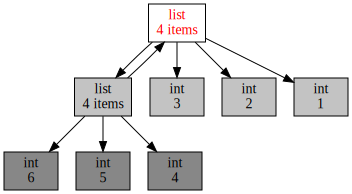

In [9]:
#!pip install objgraph

import objgraph

a = [1,2,3]
b = [4,5,6]

a.append(b)
b.append(a)

objgraph.show_refs([a])

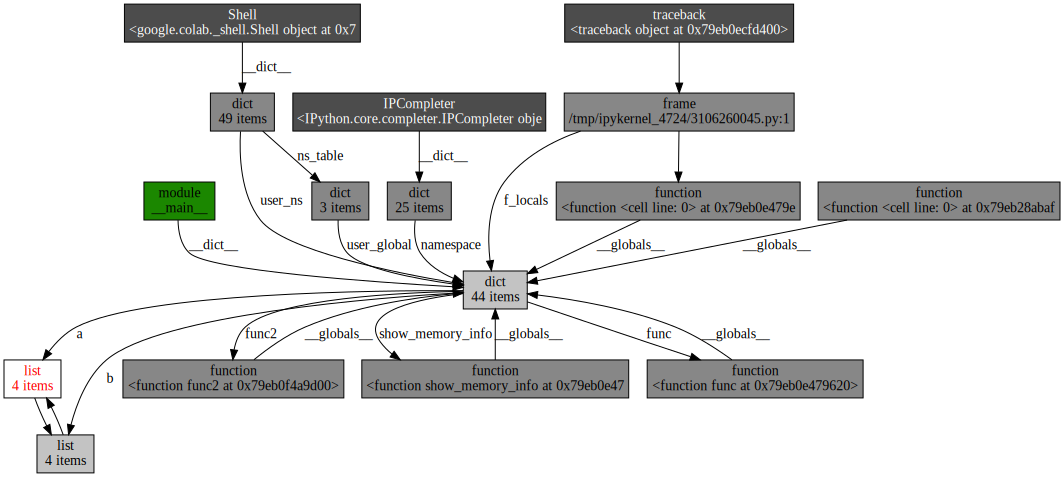

In [10]:
import objgraph

a = [1,2,3]
b = [4,5,6]

a.append(b)
b.append(a)

objgraph.show_backrefs([a])